In [24]:
import json 
from pathlib import Path
path = Path("data/mitre_attack.json") 

data = json.loads(path.read_text())

techniques = [o for o in data["objects"]
                  if o.get("type") == "attack-pattern" and not o.get("revoked")]
print(len(techniques))
for obj in techniques:
            # Extract T-ID
            refs = obj.get("external_references", [])
            tid  = next((e["external_id"] for e in refs
                         if e.get("source_name") == "mitre-attack"), "")
            if not tid:
                print('not tid')
                continue
            name     = obj.get("name", "")
            desc     = (obj.get("description") or "")[:500]
            platforms= obj.get("x_mitre_platforms", [])
            phases   = obj.get("kill_chain_phases", [])
            tactics  = [p["phase_name"] for p in phases]
            # print(f"{tid}\n{name}\n\n{desc}\n\n{','.join(platforms)}\n\n{','.join(tactics)}")
            is_sub = obj.get("x_mitre_is_subtechnique", False)
            parent_id = tid.split(".")[0] if "." in tid else None
            print(f"{tid} (subtechnique: {is_sub}, parent: {parent_id})\n{name}\n\n{desc}\n\n{','.join(platforms)}\n\n{','.join(tactics)}")
            
            


703
T1055.011 (subtechnique: True, parent: T1055)
Extra Window Memory Injection

Adversaries may inject malicious code into process via Extra Window Memory (EWM) in order to evade process-based defenses as well as possibly elevate privileges. EWM injection is a method of executing arbitrary code in the address space of a separate live process. 

Before creating a window, graphical Windows-based processes must prescribe to or register a windows class, which stipulate appearance and behavior (via windows procedures, which are functions that handle input/output of data).(Citati

Windows

defense-evasion,privilege-escalation
T1053.005 (subtechnique: True, parent: T1053)
Scheduled Task

Adversaries may abuse the Windows Task Scheduler to perform task scheduling for initial or recurring execution of malicious code. There are multiple ways to access the Task Scheduler in Windows. The [schtasks](https://attack.mitre.org/software/S0111) utility can be run directly on the command line, or the Ta

In [21]:
print(techniques[-1])

{'type': 'attack-pattern', 'id': 'attack-pattern--ffeb0780-356e-4261-b036-cfb6bd234335', 'created': '2020-06-24T22:30:55.843Z', 'created_by_ref': 'identity--c78cb6e5-0c4b-4611-8297-d1b8b55e40b5', 'external_references': [{'source_name': 'mitre-attack', 'url': 'https://attack.mitre.org/techniques/T1574/012', 'external_id': 'T1574.012'}, {'source_name': 'Microsoft Profiling Mar 2017', 'description': 'Microsoft. (2017, March 30). Profiling Overview. Retrieved June 24, 2020.', 'url': 'https://docs.microsoft.com/en-us/dotnet/framework/unmanaged-api/profiling/profiling-overview'}, {'source_name': 'Microsoft COR_PROFILER Feb 2013', 'description': 'Microsoft. (2013, February 4). Registry-Free Profiler Startup and Attach. Retrieved June 24, 2020.', 'url': 'https://docs.microsoft.com/en-us/previous-versions/dotnet/netframework-4.0/ee471451(v=vs.100)'}, {'source_name': 'RedCanary Mockingbird May 2020', 'description': 'Lambert, T. (2020, May 7). Introducing Blue Mockingbird. Retrieved May 26, 2020.

In [20]:
print(f"{tid}\n{name}\n\n{desc}\n\n{','.join(platforms)}\n\n{','.join(tactics)}")

T1574.012
COR_PROFILER

Adversaries may leverage the COR_PROFILER environment variable to hijack the execution flow of programs that load the .NET CLR. The COR_PROFILER is a .NET Framework feature which allows developers to specify an unmanaged (or external of .NET) profiling DLL to be loaded into each .NET process that loads the Common Language Runtime (CLR). These profilers are designed to monitor, troubleshoot, and debug managed code executed by the .NET CLR.(Citation: Microsoft Profiling Mar 2017)(Citation: Microso

Windows

persistence,privilege-escalation,defense-evasion


In [ ]:
A = 555

In [1]:
import numpy as np
import numpy.linalg as la
import numpy.random as rd
import matplotlib.pyplot as plt

A = np.array([[0,   0.7, 0.3],
              [0.3, 0.4, 0.3],
              [0.5, 0.5, 0.0]])


n = 5
M = la.matrix_power(A, n)   # calcule A^n


In [2]:
for k in [5, 10, 20]:
    M = la.matrix_power(A, k)
    print(f'A^{k} =')
    print(np.round(M, 4))
    print()


A^5 =
[[0.2626 0.506  0.2313]
 [0.265  0.5036 0.2313]
 [0.2732 0.498  0.2289]]

A^10 =
[[0.2663 0.5029 0.2308]
 [0.2663 0.503  0.2308]
 [0.2662 0.503  0.2308]]

A^20 =
[[0.2663 0.503  0.2308]
 [0.2663 0.503  0.2308]
 [0.2663 0.503  0.2308]]



In [ ]:
V1 = A[1]         
V0 = np.array([0, 1, 0])
V1 = V0 @ A    # lien entre V1 et A   
print(V1)         



[0.3 0.4 0.3]


In [4]:
def SimuX1():
    u = rd.random()      
    if u < 0.3:
        return 1          
    elif u < 0.7:         
        return 2          
    else:                 
        return 3         


In [5]:
def SimuMarkovEtape(x0, A):
    ligne = A[x0 - 1]         
    u = rd.random()
    cumul = 0
    for j, prob in enumerate(ligne):
        cumul += prob
        if u < cumul:
            return j + 1 


In [6]:
def SimuMarkov(x0, A, n):
    etat = x0
    for i in range(n):              
        etat = SimuMarkovEtape(etat, A)
    return etat                     


In [8]:
def SimuTrajectoire(x0, A, n):
    traj = [x0]                         
    for i in range(n):
        prochain = SimuMarkovEtape(traj[-1], A)
        traj.append(prochain)
    return traj   


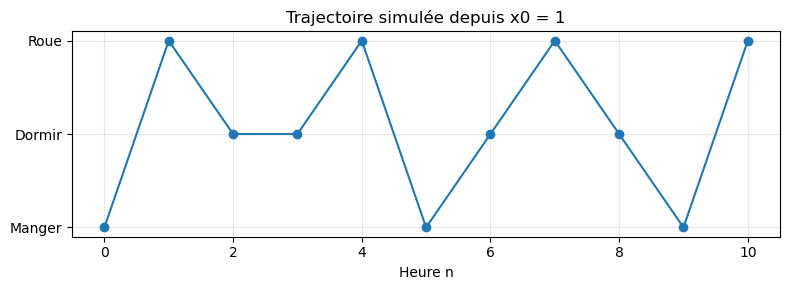

In [11]:
x0 = 1
n  = 10
traj = SimuTrajectoire(x0, A, n)

plt.figure(figsize=(8, 3))
plt.plot(range(n + 1), traj, marker='o', linestyle='-')
plt.yticks([1, 2, 3], ['Manger', 'Dormir', 'Roue'])
plt.xlabel('Heure n')
plt.title(f'Trajectoire simulée depuis x0 = {x0}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
V0 = np.zeros(3)
V0[x0 - 1] = 1     
Vn = V0 @ M         

def PremTermesLoiXn(x0, A, n):
    V = np.zeros((n + 1, 3))    # matrice résultat : (n+1) lignes, 3 colonnes
    M = np.eye(3)            # vecteur initial selon x0
    for k in range(n + 1):
        V[k] = V0 @ M           # ligne k = loi de X_k
        M = np.dot(M, A)        # M devient A^(k+1) pour l'itération suivante
    return V


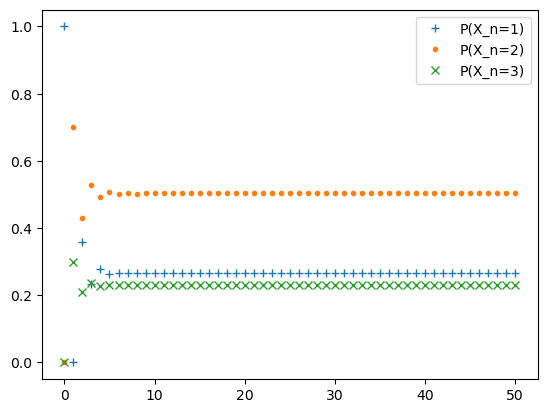

In [15]:
n = 50
x0 = 1
Y = range (n+1)
V = PremTermesLoiXn(x0, A, n)
plt.plot(Y, V[:,0],'+', label='P(X_n=1)')
plt.plot(Y, V[:,1],'.', label='P(X_n=2)')
plt.plot(Y, V[:,2],'x', label='P(X_n=3)')
plt.legend(loc='best')

In [19]:
import numpy as np
A = np.array([[0,   0.7, 0.3],
              [0.3, 0.4, 0.3],
              [0.5, 0.5, 0.0]])
print(A)
B = np.array([[0, 1/3, 2/3],
              [1/2, 0, 1/2],
              [1/4, 3/4, 0]])
p =np.linalg.matrix_power(B, 3)
print(p)

[[0.  0.7 0.3]
 [0.3 0.4 0.3]
 [0.5 0.5 0. ]]
[[0.29166667 0.23611111 0.47222222]
 [0.35416667 0.29166667 0.35416667]
 [0.17708333 0.53125    0.29166667]]


In [17]:
V0 = np.array([0, 1, 0])
V1 = V0 @ A       
